In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving student_data.csv to student_data (1).csv


In [4]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [5]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [6]:
X = df.drop(columns=['G3'])
y = df['G3']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (395, 32)
Target: (395,)


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Processed shape:", X_processed.shape)

Processed shape: (395, 58)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 58)
Testing data: (79, 58)


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("Random Forest - Bagging")
print("Train R2:", r2_score(y_train, rf_train_pred))
print("Test R2:", r2_score(y_test, rf_test_pred))
print("Test RMSE:", mean_squared_error(y_test, rf_test_pred) ** 0.5)

Random Forest - Bagging
Train R2: 0.9831860755106138
Test R2: 0.8056435298346514
Test RMSE: 1.9963187640241566


In [10]:
!pip install -q xgboost

In [11]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

print("XGBoost - Boosting")
print("Train R2:", r2_score(y_train, xgb_train_pred))
print("Test R2:", r2_score(y_test, xgb_test_pred))
print("Test RMSE:", mean_squared_error(y_test, xgb_test_pred) ** 0.5)

XGBoost - Boosting
Train R2: 0.9727594256401062
Test R2: 0.8066918253898621
Test RMSE: 1.9909278627257283


In [12]:
!pip install -q lightgbm

In [13]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train, y_train)

lgbm_train_pred = lgbm.predict(X_train)
lgbm_test_pred = lgbm.predict(X_test)

print("LightGBM - Boosting")
print("Train R2:", r2_score(y_train, lgbm_train_pred))
print("Test R2:", r2_score(y_test, lgbm_test_pred))
print("Test RMSE:", mean_squared_error(y_test, lgbm_test_pred) ** 0.5)

LightGBM - Boosting
Train R2: 0.9608628019301657
Test R2: 0.8202553434444824
Test RMSE: 1.919810584108021


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [14]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Train R2': [
        r2_score(y_train, rf_train_pred),
        r2_score(y_train, xgb_train_pred),
        r2_score(y_train, lgbm_train_pred)
    ],
    'Test R2': [
        r2_score(y_test, rf_test_pred),
        r2_score(y_test, xgb_test_pred),
        r2_score(y_test, lgbm_test_pred)
    ],
    'Test RMSE': [
        mean_squared_error(y_test, rf_test_pred) ** 0.5,
        mean_squared_error(y_test, xgb_test_pred) ** 0.5,
        mean_squared_error(y_test, lgbm_test_pred) ** 0.5
    ]
})

print(results)

           Model  Train R2   Test R2  Test RMSE
0  Random Forest  0.983186  0.805644   1.996319
1        XGBoost  0.972759  0.806692   1.990928
2       LightGBM  0.960863  0.820255   1.919811


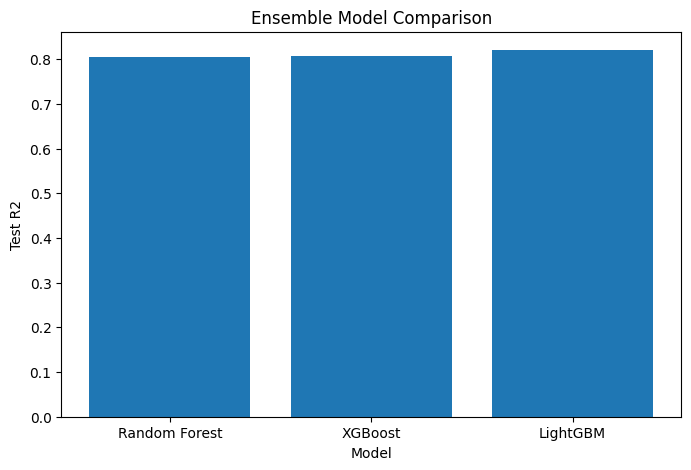

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results['Model'], results['Test R2'])

plt.xlabel("Model")
plt.ylabel("Test R2")
plt.title("Ensemble Model Comparison")

plt.show()

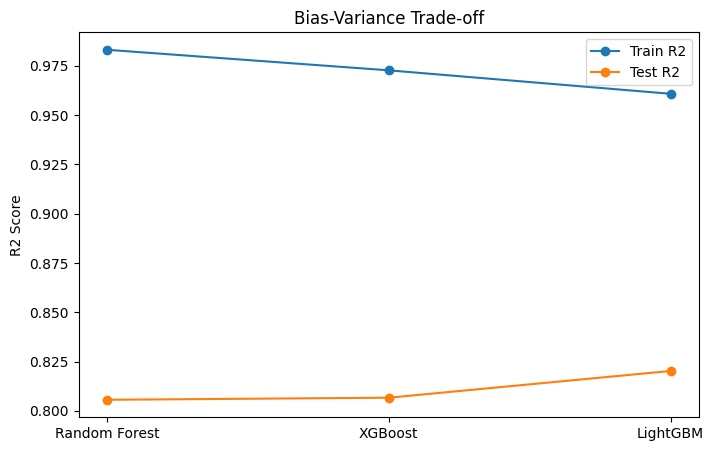

In [16]:
plt.figure(figsize=(8, 5))

x = range(len(results))

plt.plot(x, results['Train R2'], marker='o', label='Train R2')
plt.plot(x, results['Test R2'], marker='o', label='Test R2')

plt.xticks(x, results['Model'])
plt.ylabel("R2 Score")
plt.title("Bias-Variance Trade-off")
plt.legend()

plt.show()

In [17]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lasso_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('lasso', Lasso(alpha=0.1))
])

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

print("L1 Regularization - Lasso")
print("Test R2:", r2_score(y_test, lasso_pred))
print("Test RMSE:", mean_squared_error(y_test, lasso_pred) ** 0.5)

L1 Regularization - Lasso
Test R2: 0.7721776127704528
Test RMSE: 2.1613673493567687


In [18]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('ridge', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("L2 Regularization - Ridge")
print("Test R2:", r2_score(y_test, ridge_pred))
print("Test RMSE:", mean_squared_error(y_test, ridge_pred) ** 0.5)

L2 Regularization - Ridge
Test R2: 0.7245925886372259
Test RMSE: 2.3763926417933097


In [19]:
regularization_results = pd.DataFrame({
    'Model': ['L1 - Lasso', 'L2 - Ridge'],
    'Test R2': [
        r2_score(y_test, lasso_pred),
        r2_score(y_test, ridge_pred)
    ],
    'Test RMSE': [
        mean_squared_error(y_test, lasso_pred) ** 0.5,
        mean_squared_error(y_test, ridge_pred) ** 0.5
    ]
})

print(regularization_results)

        Model   Test R2  Test RMSE
0  L1 - Lasso  0.772178   2.161367
1  L2 - Ridge  0.724593   2.376393
